In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from IPython.display import FileLink, display

import warnings
warnings.filterwarnings("ignore")

In [12]:
filename = "heart-disease.csv"

print("Current Jupyter folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

if not os.path.exists(filename):
    raise FileNotFoundError(
        "heart-disease.csv was not found. "
        "Put the file in the same folder as your Jupyter Notebook."
    )

df = pd.read_csv(filename)

print("\nDataset loaded successfully!")
print("Dataset:", filename)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Current Jupyter folder:
C:\Users\HP

Files in current folder:
['.cache', '.claude', '.claude.json', '.copilot', '.dbvis', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.matplotlib', '.ms-ad', '.node_repl_history', '.openjfx', '.redhat', '.streamlit', '.vscode', '.vscode-dictation', '.vscode-shared', 'AML_Individual_Task.ipynb', 'app', 'AppData', 'Application Data', 'archive.zip', 'confusion_matrix.png', 'Contacts', 'Cookies', 'dataset', 'Documents', 'Downloads', 'Favorites', 'Figure_1.png', 'heart-disease.csv', 'heart_disease_model_results.csv', 'languge.html', 'Links', 'Local Settings', 'models', 'Music', 'My Documents', 'NetHood', 'node_modules', 'notebooks', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{9cf10d26-d2ea-11f0-adb3-2c7ba09bc32c}.TM.blf', 'NTUSER.DAT{9cf10d26-d2ea-11f0-adb3-2c7ba09bc32c}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{9cf10d26-d2ea-11f0-adb3-2c7ba09bc32c}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'o

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [13]:
print("Column names:")
print(df.columns.tolist())

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print("\nCleaned column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nDataset shape after removing duplicates:")
print(df.shape)

print("\nStatistical Summary:")
display(df.describe(include="all"))

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Cleaned column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows:
1

Dataset shape after removing duplicates:
(302, 14)

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
possible_targets = [
    "target",
    "condition",
    "heartdisease",
    "heart_disease",
    "output",
    "label",
    "class",
    "num"
]

target_column = None

for col in possible_targets:
    if col in df.columns:
        target_column = col
        break

if target_column is None:
    print("Target column was not automatically detected.")
    print("Available columns:")
    print(df.columns.tolist())

    target_column = input(
        "\nEnter your target column name: "
    ).strip().lower()

if target_column not in df.columns:
    raise ValueError(
        f"Target column '{target_column}' was not found."
    )

print("\nTarget column:", target_column)

print("\nTarget Distribution:")
print(df[target_column].value_counts())


Target column: target

Target Distribution:
target
1    164
0    138
Name: count, dtype: int64


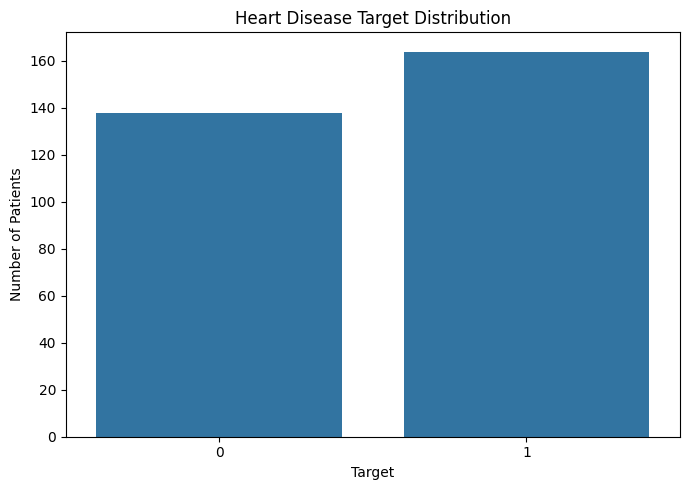

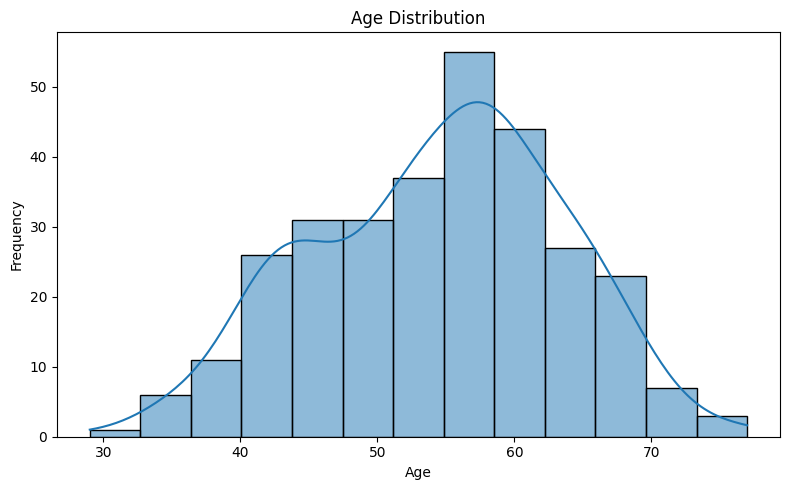

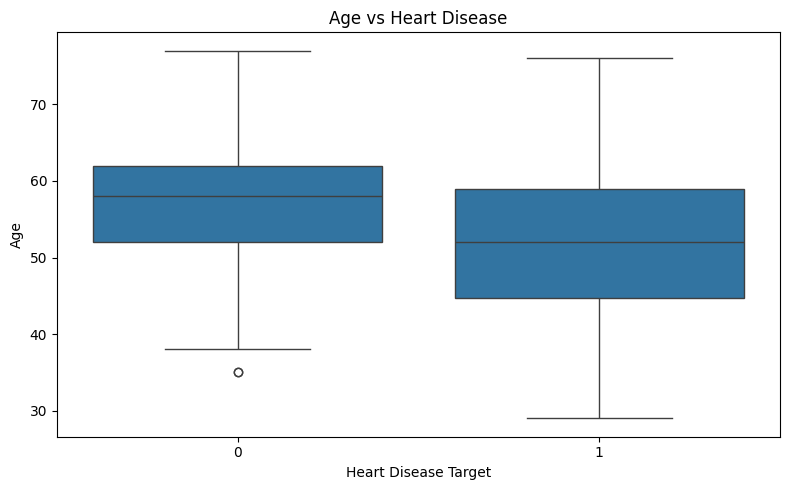

In [9]:
# Target distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    x=target_column,
    data=df
)

plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


# Age distribution
if "age" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        df["age"],
        kde=True
    )

    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# Age vs target
if "age" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x=target_column,
        y="age",
        data=df
    )

    plt.title("Age vs Heart Disease")
    plt.xlabel("Heart Disease Target")
    plt.ylabel("Age")

    plt.tight_layout()
    plt.show()

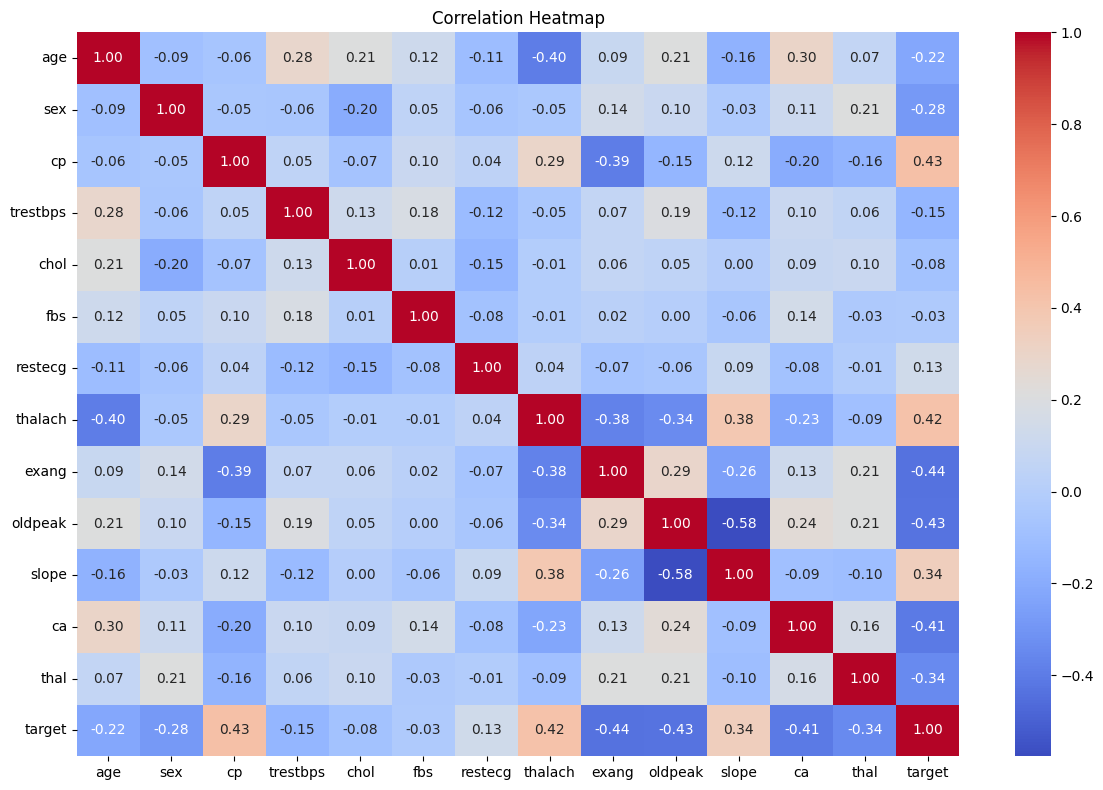

In [10]:
numeric_df = df.select_dtypes(
    include=np.number
)

if numeric_df.shape[1] > 1:

    plt.figure(figsize=(12, 8))

    sns.heatmap(
        numeric_df.corr(),
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )

    plt.title("Correlation Heatmap")

    plt.tight_layout()
    plt.show()

In [14]:
X = df.drop(
    target_column,
    axis=1
)

y = df[target_column]

id_columns = []

for col in X.columns:

    if col.lower() in [
        "id",
        "patient_id",
        "patientid"
    ]:
        id_columns.append(col)

if len(id_columns) > 0:
    X = X.drop(columns=id_columns)

X = pd.get_dummies(
    X,
    drop_first=True
)

if not pd.api.types.is_numeric_dtype(y):
    y = pd.factorize(y)[0]

print("Features and target prepared.")
print("\nFeature shape:")
print(X.shape)

print("\nFeatures:")
print(X.columns.tolist())

Features and target prepared.

Feature shape:
(302, 13)

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [15]:
imputer = SimpleImputer(
    strategy="median"
)

X_imputed = imputer.fit_transform(X)

X = pd.DataFrame(
    X_imputed,
    columns=X.columns
)

print("Missing values handled successfully.")

print("\nFinal feature shape:")
print(X.shape)

print("\nRemaining missing values:")
print(X.isnull().sum().sum())

Missing values handled successfully.

Final feature shape:
(302, 13)

Remaining missing values:
0


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:")
print(X_train.shape[0])

print("\nTesting samples:")
print(X_test.shape[0])

Training samples:
241

Testing samples:
61


In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature scaling completed.")

Feature scaling completed.


In [18]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = logistic_model.predict(
    X_test_scaled
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [19]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(
    X_train,
    y_train
)

y_pred_dt = decision_tree_model.predict(
    X_test
)

print("Decision Tree trained successfully.")

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(
    X_train,
    y_train
)

y_pred_rf = random_forest_model.predict(
    X_test
)

print("Random Forest trained successfully.")

Decision Tree trained successfully.
Random Forest trained successfully.


In [20]:
def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "Algorithm": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }


results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_dt
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf
    )
)

results_df = pd.DataFrame(results)

print("=" * 70)
print("MODEL RESULTS")
print("=" * 70)

display(results_df)


results_percentage = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

for metric in metric_columns:
    results_percentage[metric] = (
        results_percentage[metric] * 100
    ).round(2)

print("\nRESULTS IN PERCENTAGE")

display(results_percentage)

MODEL RESULTS


,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.786885,0.792043,0.786885,0.783942
1,Decision Tree,0.721311,0.723656,0.721311,0.717463
2,Random Forest,0.786885,0.799180,0.786885,0.781881



RESULTS IN PERCENTAGE


,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,78.69,79.20,78.69,78.39
1,Decision Tree,72.13,72.37,72.13,71.75
2,Random Forest,78.69,79.92,78.69,78.19



Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.68      0.75        28
           1       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61



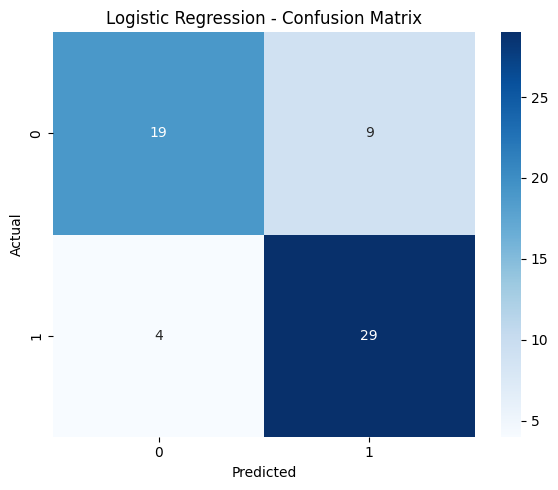


Decision Tree
              precision    recall  f1-score   support

           0       0.74      0.61      0.67        28
           1       0.71      0.82      0.76        33

    accuracy                           0.72        61
   macro avg       0.72      0.71      0.71        61
weighted avg       0.72      0.72      0.72        61



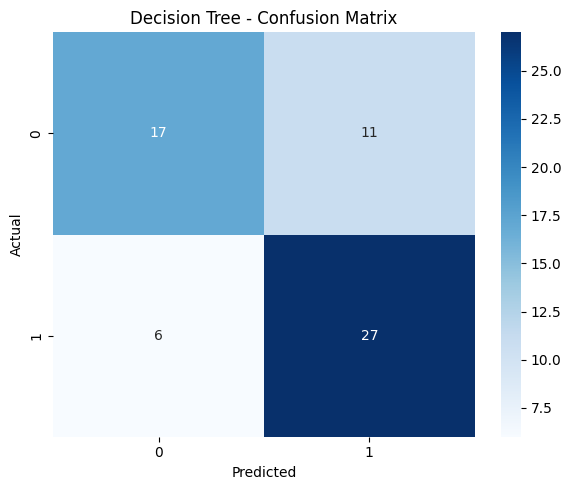


Random Forest
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



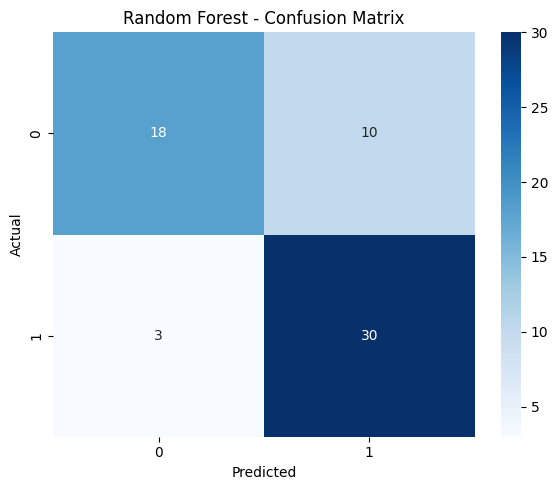

In [21]:
models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

for model_name, predictions in models.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

DECISION TREE VISUALIZATION


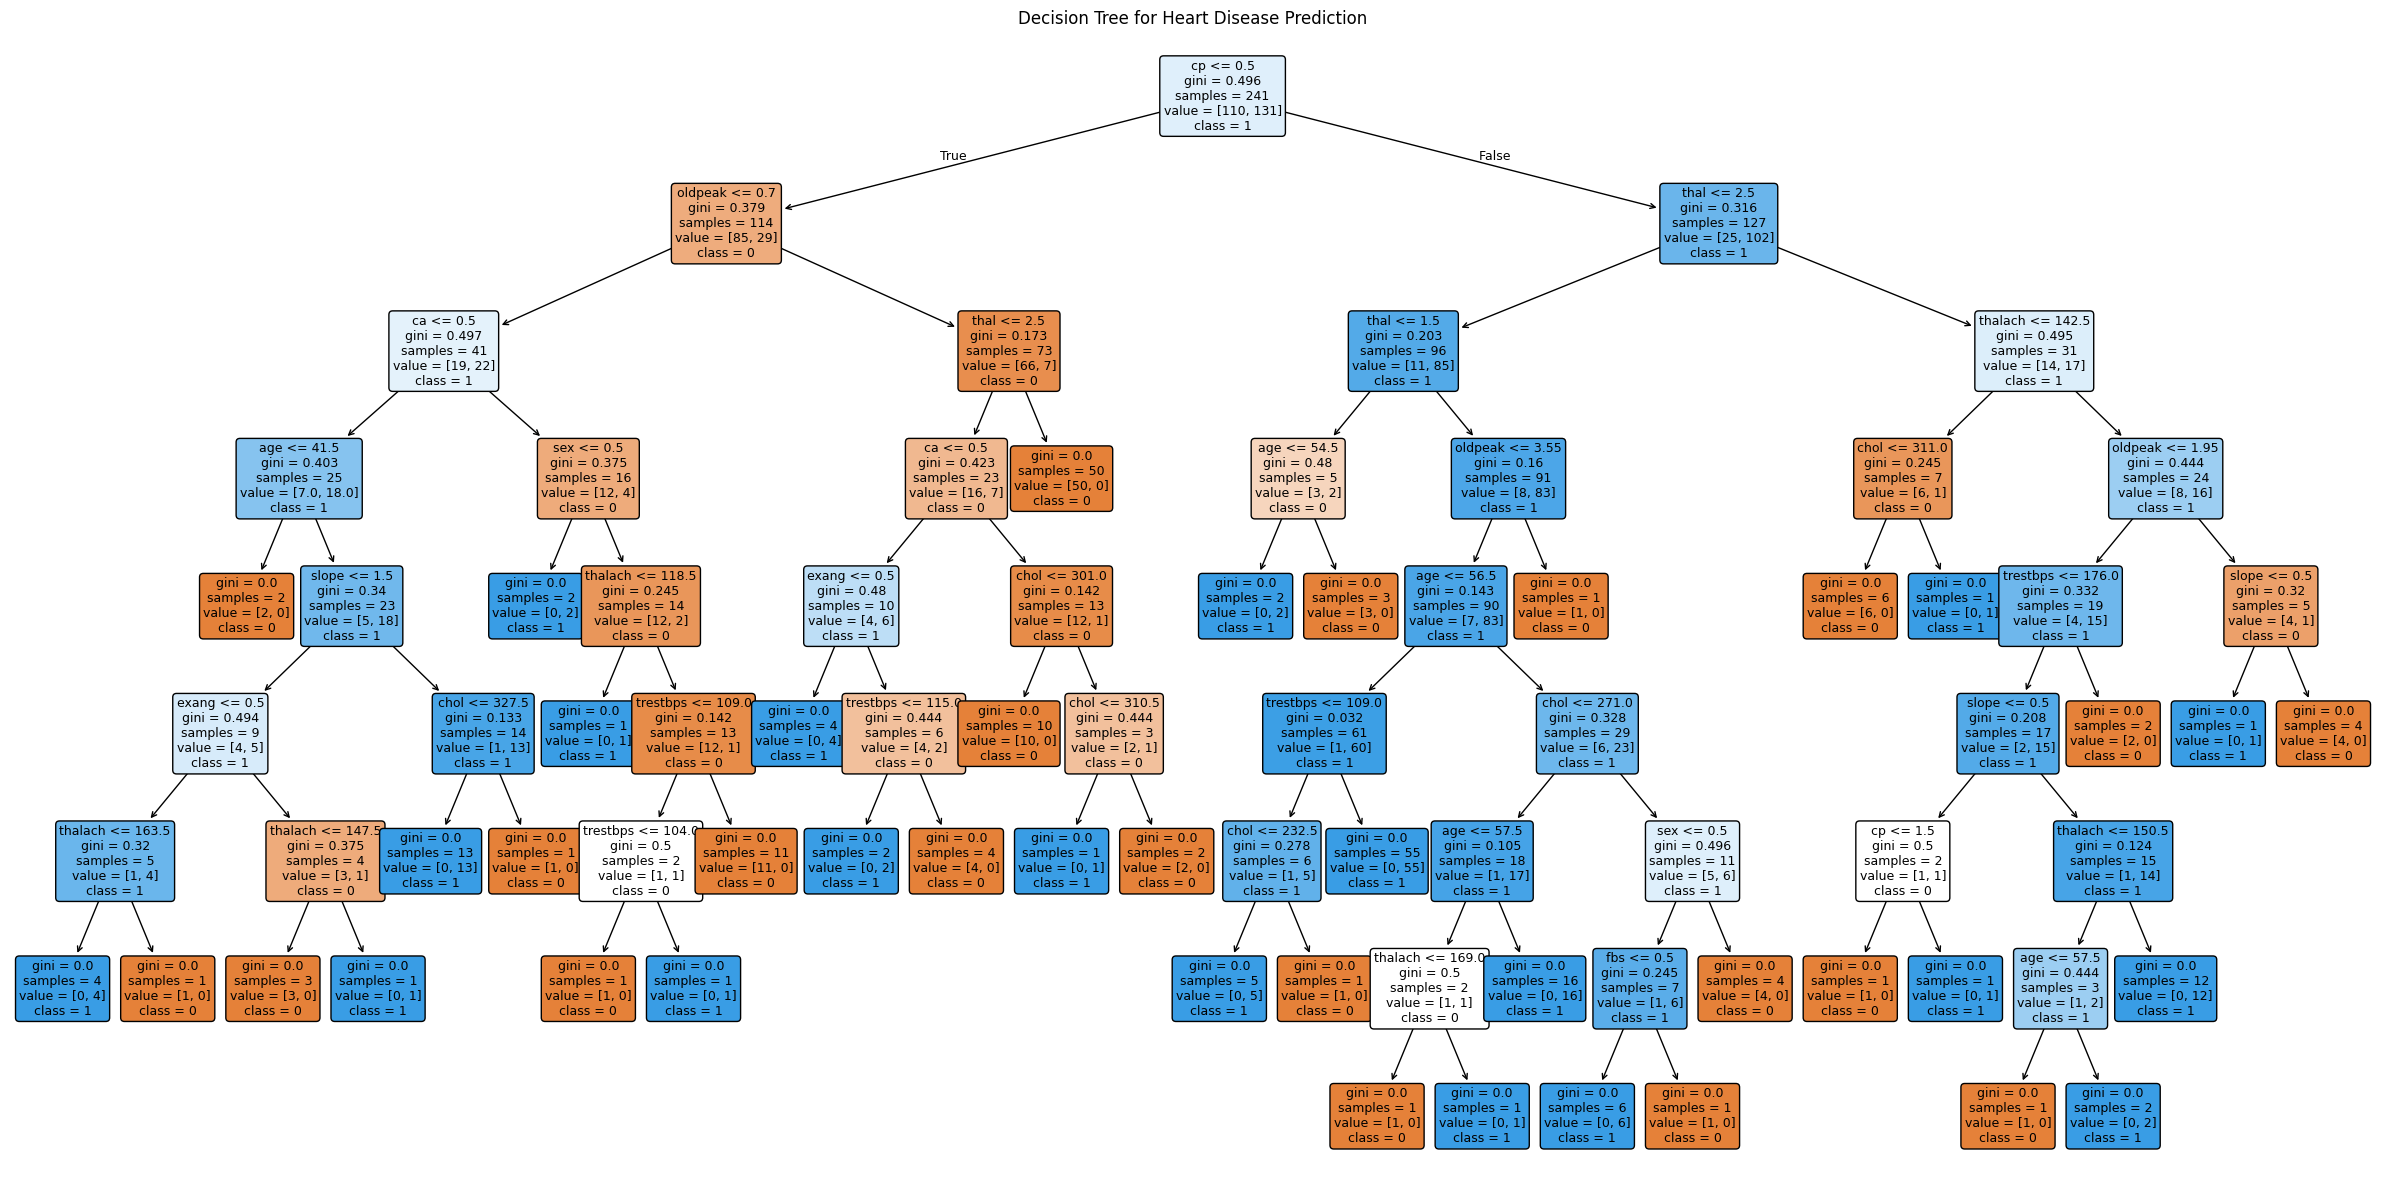

In [22]:
print("=" * 70)
print("DECISION TREE VISUALIZATION")
print("=" * 70)

plt.figure(figsize=(24, 12))

plot_tree(
    decision_tree_model,
    feature_names=X.columns,
    class_names=[
        str(c)
        for c in sorted(pd.Series(y).unique())
    ],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    "Decision Tree for Heart Disease Prediction"
)

plt.tight_layout()
plt.show()

DECISION TREE FEATURE IMPORTANCE


,Feature,Importance
2,cp,0.310925
9,oldpeak,0.122348
12,thal,0.089707
4,chol,0.077418
7,thalach,0.076846
0,age,0.069430
3,trestbps,0.063551
11,ca,0.061908
1,sex,0.052780
10,slope,0.031670


RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
2,cp,0.155435
7,thalach,0.121677
9,oldpeak,0.117138
12,thal,0.108110
11,ca,0.090095
4,chol,0.086392
0,age,0.083014
3,trestbps,0.072683
8,exang,0.058521
10,slope,0.046025


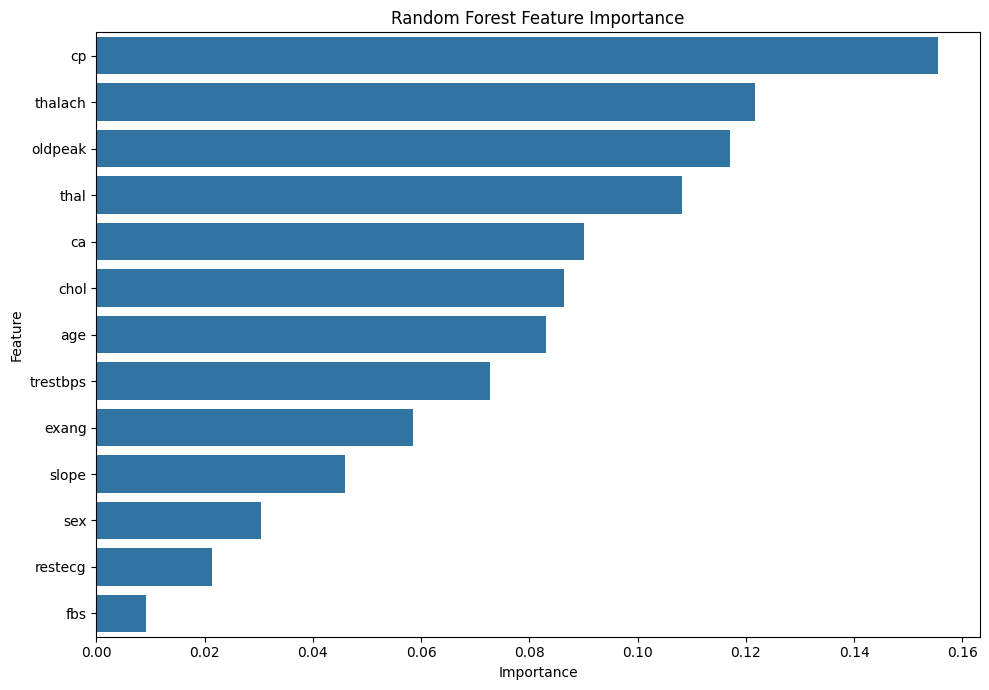

In [28]:
decision_tree_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        decision_tree_model.feature_importances_

})

decision_tree_importance = (
    decision_tree_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print("=" * 70)
print("DECISION TREE FEATURE IMPORTANCE")
print("=" * 70)

display(decision_tree_importance)


feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        random_forest_model.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print("=" * 70)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

display(feature_importance)


plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

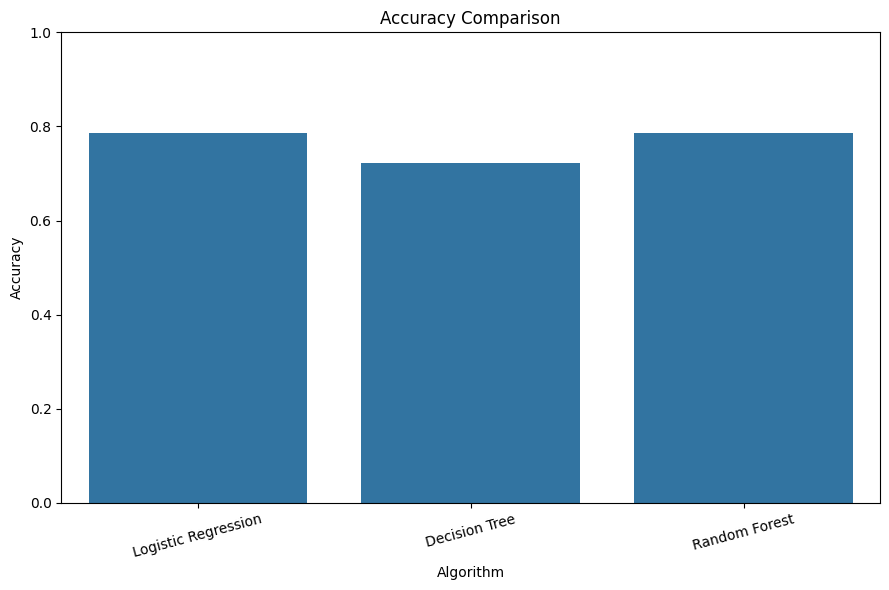

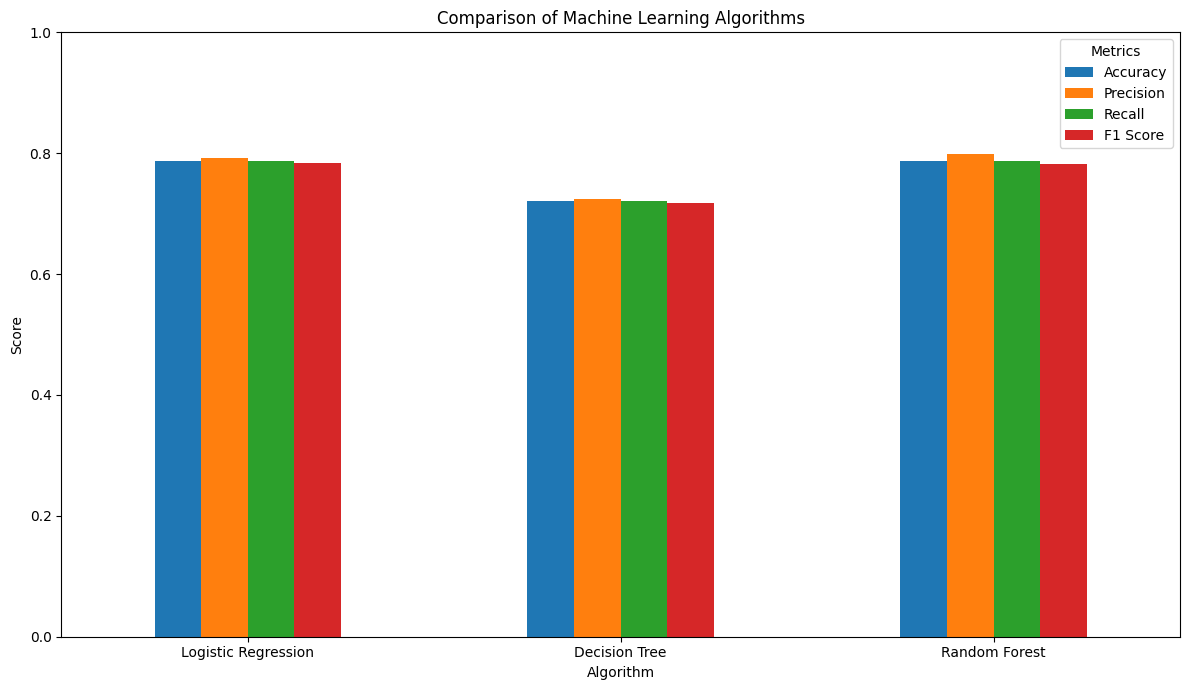

In [24]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=results_df,
    x="Algorithm",
    y="Accuracy"
)

plt.title("Accuracy Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


plot_df = results_df.set_index(
    "Algorithm"
)

plot_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Comparison of Machine Learning Algorithms"
)

plt.xlabel("Algorithm")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Metrics"
)

plt.tight_layout()
plt.show()

In [25]:
best_index = results_df[
    "F1 Score"
].idxmax()

best_algorithm = results_df.loc[
    best_index,
    "Algorithm"
]

best_accuracy = results_df.loc[
    best_index,
    "Accuracy"
]

best_precision = results_df.loc[
    best_index,
    "Precision"
]

best_recall = results_df.loc[
    best_index,
    "Recall"
]

best_f1 = results_df.loc[
    best_index,
    "F1 Score"
]

print("=" * 70)
print("BEST PERFORMING ALGORITHM")
print("=" * 70)

print("\nAlgorithm:", best_algorithm)

print(
    "Accuracy:",
    round(best_accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(best_precision * 100, 2),
    "%"
)

print(
    "Recall:",
    round(best_recall * 100, 2),
    "%"
)

print(
    "F1 Score:",
    round(best_f1 * 100, 2),
    "%"
)

BEST PERFORMING ALGORITHM

Algorithm: Logistic Regression
Accuracy: 78.69 %
Precision: 79.2 %
Recall: 78.69 %
F1 Score: 78.39 %


In [26]:
results_percentage.to_csv(
    "heart_disease_model_results.csv",
    index=False
)

feature_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

print("=" * 70)
print("RESULT FILES CREATED")
print("=" * 70)

print("\nheart_disease_model_results.csv")
print("random_forest_feature_importance.csv")

print("\nDownload links:")

display(
    FileLink(
        "heart_disease_model_results.csv"
    )
)

display(
    FileLink(
        "random_forest_feature_importance.csv"
    )
)

RESULT FILES CREATED

heart_disease_model_results.csv
random_forest_feature_importance.csv

Download links:


C:\Users\HP\heart_disease_model_results.csv

C:\Users\HP\random_forest_feature_importance.csv

In [27]:
print("=" * 70)
print("FINAL PROJECT CONCLUSION")
print("=" * 70)

print(
    "\nThree machine learning algorithms were applied:"
)

print("1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest")

print(
    "\nThe algorithms were compared using:"
)

print(
    "Accuracy, Precision, Recall, and F1 Score."
)

print(
    f"\nThe best-performing algorithm based on F1 Score "
    f"is {best_algorithm}."
)

print(
    f"\nAccuracy: {best_accuracy * 100:.2f}%"
)

print(
    f"Precision: {best_precision * 100:.2f}%"
)

print(
    f"Recall: {best_recall * 100:.2f}%"
)

print(
    f"F1 Score: {best_f1 * 100:.2f}%"
)

print(
    f"\nTherefore, {best_algorithm} is selected as the "
    "best-performing algorithm for this dataset."
)

print("\nPROJECT COMPLETED SUCCESSFULLY!")

print("=" * 70)

FINAL PROJECT CONCLUSION

Three machine learning algorithms were applied:
1. Logistic Regression
2. Decision Tree
3. Random Forest

The algorithms were compared using:
Accuracy, Precision, Recall, and F1 Score.

The best-performing algorithm based on F1 Score is Logistic Regression.

Accuracy: 78.69%
Precision: 79.20%
Recall: 78.69%
F1 Score: 78.39%

Therefore, Logistic Regression is selected as the best-performing algorithm for this dataset.

PROJECT COMPLETED SUCCESSFULLY!
